In [ ]:
import os
import shutil
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Unzip dataset
!unzip -q fer2013.zip -d fer2013

# Define path to the test directory
data_dir = 'fer2013'
test_dir = os.path.join(data_dir, 'test')

# Classes to remove
classes_to_remove = ['disgust', 'neutral', 'surprise']

# Function to delete unwanted class folders
def remove_classes(data_dir, classes_to_remove):
    for cls in classes_to_remove:
        class_path_test = os.path.join(test_dir, cls)
        if os.path.exists(class_path_test):
            shutil.rmtree(class_path_test)
            print(f"Removed testing class: {cls}")

# Remove unwanted classes from the test folder
remove_classes(data_dir, classes_to_remove)

# Define transformations for the test data
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((48, 48)),  # FER2013 images are 48x48
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

# Load the filtered test dataset
test_dataset = ImageFolder(root=test_dir, transform=transform)

# Create DataLoader for the test dataset
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Verify dataset loading
print(f"Number of test images: {len(test_dataset)}")
print(f"Classes in the test dataset: {test_dataset.classes}")


Removed testing class: disgust
Removed testing class: neutral
Removed testing class: surprise
Number of test images: 5003
Classes in the test dataset: ['angry', 'fear', 'happy', 'sad']


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet18

# Contrastive Loss Function
def contrastive_loss(anchor, positive, negative, margin=1.0):
    pos_dist = (anchor - positive).pow(2).sum(1)
    neg_dist = (anchor - negative).pow(2).sum(1)
    return torch.mean(F.relu(pos_dist - neg_dist + margin))

# MultiScaleBlock for Multi-Scale Feature Extraction
class MultiScaleBlock(nn.Module):
    def __init__(self, channels):
        super(MultiScaleBlock, self).__init__()
        self.conv3 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(channels, channels, kernel_size=5, padding=2)
        self.conv7 = nn.Conv2d(channels, channels, kernel_size=7, padding=3)

    def forward(self, x):
        x3 = self.conv3(x)
        x5 = self.conv5(x)
        x7 = self.conv7(x)
        return x3 + x5 + x7  # Combine multi-scale features

# Attention Block
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        batch, channels, _, _ = x.size()
        y = torch.mean(x.view(batch, channels, -1), dim=2)
        y = self.fc(y).view(batch, channels, 1, 1)
        return x * y

# Updated Emotion Classifier with Multi-Scale and Contrastive Loss Integration
class EmotionClassifierWithAttention(nn.Module):
    def __init__(self, num_classes=4):
        super(EmotionClassifierWithAttention, self).__init__()
        # Shared feature extractor
        base_model = resnet18(pretrained=True)

        # Modify the first convolutional layer to accept 1 channel input
        base_model.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)

        self.feature_extractor = nn.Sequential(*list(base_model.children())[:-2])  # Exclude FC layer

        # Multi-Scale Block for feature refinement
        self.multi_scale_block = MultiScaleBlock(512)

        # Attention for each region
        self.se_block_eyes = SEBlock(512)
        self.se_block_mouth = SEBlock(512)
        self.se_block_eyebrows = SEBlock(512)

        # Fully connected layer
        self.fc = nn.Sequential(
            nn.Linear(3072, 256),  # Use 3072 as the input size
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        batch_size, _, _, _ = x.size()

        # Divide image into regions (simplified for FER2013; no landmarks)
        eyes = x[:, :, :24, :]  # Top half for eyes
        mouth = x[:, :, 24:, :]  # Bottom half for mouth
        eyebrows = x[:, :, :16, :]  # Top quarter for eyebrows

        # Shared feature extraction
        eyes_features = self.feature_extractor(eyes)
        mouth_features = self.feature_extractor(mouth)
        eyebrows_features = self.feature_extractor(eyebrows)

        # Apply multi-scale block to each region
        eyes_features = self.multi_scale_block(eyes_features)
        mouth_features = self.multi_scale_block(mouth_features)
        eyebrows_features = self.multi_scale_block(eyebrows_features)

        # Apply attention to each region
        eyes_attention = self.se_block_eyes(eyes_features)
        mouth_attention = self.se_block_mouth(mouth_features)
        eyebrows_attention = self.se_block_eyebrows(eyebrows_features)

        # Flatten and concatenate features
        eyes_flat = torch.flatten(eyes_attention, 1)
        mouth_flat = torch.flatten(mouth_attention, 1)
        eyebrows_flat = torch.flatten(eyebrows_attention, 1)
        combined_features = torch.cat([eyes_flat, mouth_flat, eyebrows_flat], dim=1)

        # Classification
        output = self.fc(combined_features)
        return output


In [ ]:

# Load the model and weights
emotion_model_path = "/content/best_model_weights.pth"
emotion_model = EmotionClassifierWithAttention(num_classes=4)
emotion_model.load_state_dict(torch.load(emotion_model_path))
emotion_model.eval()


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 117MB/s]
<ipython-input-3-437f5cf5ffe0>:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possib

EmotionClassifierWithAttention(
  (feature_extractor): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affin

Predicted Emotion: Happy


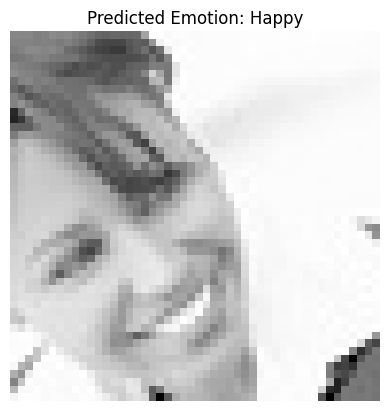

In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# Define the mapping from class indices to emotion labels
emotion_labels = {
    0: "Angry",
    1: "Sad",
    2: "Fear",
    3: "Happy"

}

# Define the image preprocessing pipeline
preprocess = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Convert to grayscale
    transforms.Resize((48, 48)),                 # Resize to 48x48
    transforms.ToTensor(),                       # Convert to tensor
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize to [-1, 1]
])

# Load happy image
image_path = "/content/fer2013/test/happy/PrivateTest_11155116.jpg"
image = Image.open(image_path)

# Preprocess the image
preprocessed_image = preprocess(image)

# Add a batch dimension
input_tensor = preprocessed_image.unsqueeze(0)  # Shape: (1, 1, 48, 48)

# Pass the image through the model
emotion_model.eval()  # Ensure the model is in evaluation mode
with torch.no_grad():  # Disable gradient computation
    output = emotion_model(input_tensor)

# Get the predicted class
predicted_class = torch.argmax(output, dim=1).item()
predicted_emotion = emotion_labels.get(predicted_class, "Unknown")

# Display the prediction
print(f"Predicted Emotion: {predicted_emotion}")

# Show the image with the prediction
plt.imshow(image, cmap="gray")
plt.title(f"Predicted Emotion: {predicted_emotion}")
plt.axis("off")
plt.show()


Predicted Emotion: Angry


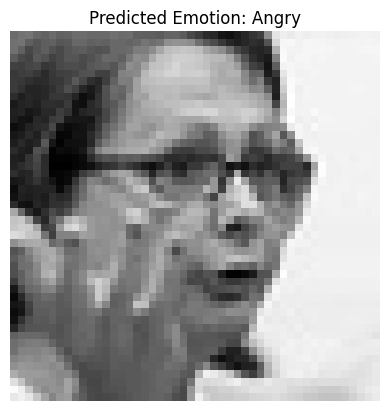

In [ ]:
# Load angry image
image_path = "/content/fer2013/test/angry/PrivateTest_13164119.jpg"
image = Image.open(image_path)

# Preprocess the image
preprocessed_image = preprocess(image)

# Add a batch dimension
input_tensor = preprocessed_image.unsqueeze(0)  # Shape: (1, 1, 48, 48)

# Pass the image through the model
emotion_model.eval()  # Ensure the model is in evaluation mode
with torch.no_grad():  # Disable gradient computation
    output = emotion_model(input_tensor)

# Get the predicted class
predicted_class = torch.argmax(output, dim=1).item()
predicted_emotion = emotion_labels.get(predicted_class, "Unknown")

# Display the prediction
print(f"Predicted Emotion: {predicted_emotion}")

# Show the image with the prediction
plt.imshow(image, cmap="gray")
plt.title(f"Predicted Emotion: {predicted_emotion}")
plt.axis("off")
plt.show()

Predicted Emotion: Sad


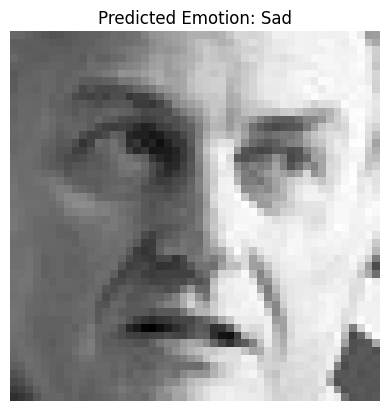

In [ ]:
# Load sad image
image_path = "/content/fer2013/test/sad/PrivateTest_10247676.jpg"
image = Image.open(image_path)

# Preprocess the image
preprocessed_image = preprocess(image)

# Add a batch dimension
input_tensor = preprocessed_image.unsqueeze(0)  # Shape: (1, 1, 48, 48)

# Pass the image through the model
emotion_model.eval()  # Ensure the model is in evaluation mode
with torch.no_grad():  # Disable gradient computation
    output = emotion_model(input_tensor)

# Get the predicted class
predicted_class = torch.argmax(output, dim=1).item()
predicted_emotion = emotion_labels.get(predicted_class, "Unknown")

# Display the prediction
print(f"Predicted Emotion: {predicted_emotion}")

# Show the image with the prediction
plt.imshow(image, cmap="gray")
plt.title(f"Predicted Emotion: {predicted_emotion}")
plt.axis("off")
plt.show()

Predicted Emotion: Fear


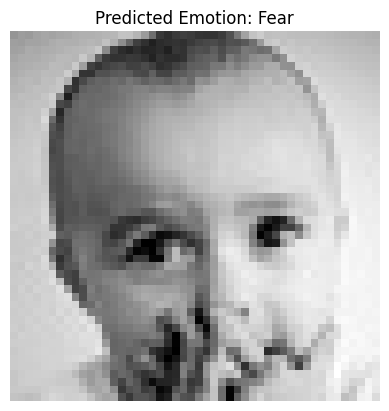

In [ ]:
# Load fear image
image_path = "/content/fer2013/test/fear/PrivateTest_48227995.jpg"
image = Image.open(image_path)

# Preprocess the image
preprocessed_image = preprocess(image)

# Add a batch dimension
input_tensor = preprocessed_image.unsqueeze(0)  # Shape: (1, 1, 48, 48)

# Pass the image through the model
emotion_model.eval()  # Ensure the model is in evaluation mode
with torch.no_grad():  # Disable gradient computation
    output = emotion_model(input_tensor)

# Get the predicted class
predicted_class = torch.argmax(output, dim=1).item()
predicted_emotion = emotion_labels.get(predicted_class, "Unknown")

# Display the prediction
print(f"Predicted Emotion: {predicted_emotion}")

# Show the image with the prediction
plt.imshow(image, cmap="gray")
plt.title(f"Predicted Emotion: {predicted_emotion}")
plt.axis("off")
plt.show()

In [ ]:
import pandas as pd

# Load the CSV file
file_path = 'ClassifiedMusicData.csv'
df = pd.read_csv(file_path)

# Define the mapping
mood_mapping = {
    'Happy': 'energetic',
    'Sad': 'cheerful',
    'Angry': 'Chill',
    'Fear': 'Chill'
}

# Predicted mood
predicted_mood = predicted_emotion

# Map the predicted mood to the corresponding CSV mood
csv_mood = mood_mapping.get(predicted_mood, None)

if csv_mood:
    # Filter rows where the mood matches the mapped mood
    filtered_rows = df[df['mood'] == csv_mood]

    # Select 5 random rows (or all if less than 5 are available)
    random_rows = filtered_rows.sample(n=5) if len(filtered_rows) >= 5 else filtered_rows

    # Format the output as "name by artist"
    formatted_output = random_rows.apply(lambda row: f"{row['name']} by {row['artist']}", axis=1)

    # Convert to a list and print
    result_list = formatted_output.tolist()
    print("Here are some songs you can listen to if you are feeling " + str(predicted_mood) + ":" , result_list)
else:
    print(f"Predicted mood '{predicted_mood}' is not in the mapping.")


Here are some songs you can listen to if you are feeling Fear: ['Nenani Neevani by Mickey J. Meyer', 'Puttadibomma by Mickey J. Meyer', 'Samaja Varagamana by Sudha Ragunathan', 'Palaraathi Bommaku by Bhanumathi Ramakrishna', 'Enna Thavam Seithanai - Instrumental by Various Artists']


## Below This is just for the report diagrams, can be ignored

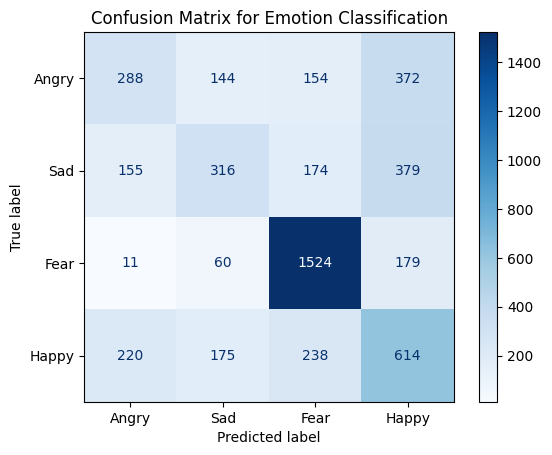

In [ ]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Ensure the model is in evaluation mode
emotion_model.eval()

# Storage for true and predicted labels
true_labels = []
predicted_labels = []

# Disable gradient computations for inference
with torch.no_grad():
    for inputs, labels in test_loader:
        # Perform a forward pass
        outputs = emotion_model(inputs)
        predictions = torch.argmax(outputs, dim=1)

        # Store true labels and predictions
        true_labels.extend(labels.numpy())
        predicted_labels.extend(predictions.numpy())

# Generate confusion matrix (raw counts)
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Map class indices to emotion labels for display
emotion_names = [emotion_labels[i] for i in range(len(emotion_labels))]

# Visualize the confusion matrix with raw counts
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=emotion_names)
disp.plot(cmap=plt.cm.Blues, values_format="d")  # "d" for integer format

# Add title and show the plot
plt.title("Confusion Matrix for Emotion Classification")
plt.show()


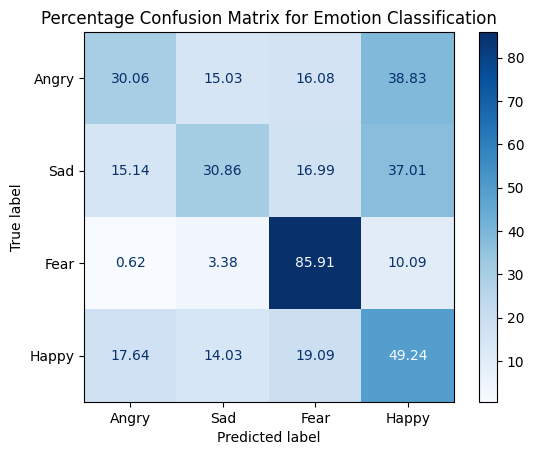

In [ ]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Ensure the model is in evaluation mode
emotion_model.eval()

# Storage for true and predicted labels
true_labels = []
predicted_labels = []

# Disable gradient computations for inference
with torch.no_grad():
    for inputs, labels in test_loader:
        # Perform a forward pass
        outputs = emotion_model(inputs)
        predictions = torch.argmax(outputs, dim=1)

        # Store true labels and predictions
        true_labels.extend(labels.numpy())
        predicted_labels.extend(predictions.numpy())

# Generate confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Normalize the confusion matrix to percentages
conf_matrix_percent = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

# Map class indices to emotion labels for display
emotion_names = [emotion_labels[i] for i in range(len(emotion_labels))]

# Visualize the percentage confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_percent, display_labels=emotion_names)
disp.plot(cmap=plt.cm.Blues, values_format=".2f")

# Add title and show the plot
plt.title("Percentage Confusion Matrix for Emotion Classification")
plt.show()
